## $\texttt{GWxLSS}$ code DEMO
This notebook shows an example on how to use the different tools in the $\texttt{GWxLSS}$ code. 
**Warining:** in order to use this notebook you need also the latest version of $\texttt{MGCAMB}$ containing the GWs features. If you do not want to use GWs make sure to not include GWC and GWWL in the observables!

In [1]:
import sys,os,re
import numpy             as np
import matplotlib.pyplot as plt
import pandas            as pd
import seaborn           as sb

from source_code.mock_maker import MakeMock

from source_code.likelihood import LSSlike

from cobaya.run import run

from copy import deepcopy

import matplotlib
from matplotlib import rc
from matplotlib.pyplot import cm
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D

rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c',

yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}

# Settings

We fix here the settings needed to produce the coefficients of the Angular Power Spectra $C_{ij}(\ell)$

- `gwspecs`: specifications for the Gravitational Waves as the Number of events (N_gw), the number of bins (Nbins_GW), the fraction of observerd sky (f_sky) and the scale cut. This last is essential since our code right now doesn't allow to work with different $\ell_{\rm max}$ for the galaxies and GWs surveys, so, since the galaxies are expect to have a higher maximum multipole, the theoretial values are computed up to their $\ell_{\rm max}$ and then all the auto and cross spectra of the GWs are cut at the requested $\ell$ value
- `galspecs`: specifications for the galaxy surveys as the Number of galaxies per arcmin (gal_per_arcmin), the number of bins (Nbins_gal), the fraction of observerd sky (f_sky) and the error
- `obs_settings`: you can specify if you want relativistic effects (cases), which observables you want to simulate (obs_used). Photometric Galaxy Clustering (GC), Weak Lensing (WL), Gravitational Waves Number Counts (GWC) and Graviational Waves Weak Lensing (GWWL) are available. 
- `camb_path`: **insert the path of $\texttt{MGCAMB}$**
- `fiducial`: value of the cosmological parameters
- `test_parameter`: parameter over which to run the likelihood 

## Options

In [2]:
observables = ['GC','WL', 'GWC','GWWL']
camb_path   = ''

## Specifications

In [3]:
gwspecs  = {'Nbins_GW': 6,
            'N_gw': int(1.e6),
            'sigma_eps_gw': 0.01,
            'fsky': 0.35,
            'scale_cut': {'method': 'ell_cut', 'value': 200}}
galspecs = {'fsky': 0.35,
            'Nbins_gal': 10,
            'gal_per_arcmin': 30.,
            'sigma_eps': 0.3}
obs_settings = {'extra': None,
               'cases': None, #['redshift', 'lensing', 'velocity', 'potential', 'lsd', 'evolve', 'potential', 'gradpotential', 'ISW', 'SW', 'volume']
               'obs_used': observables,
               'camb_path': camb_path}

# Fiducial

In [4]:
fiducial = {'ombh2': 0.022445,
            'omch2': 0.1205579307,
            'H0': 67.,
            'ns': 0.96,
            'logA': 3.05685,
            'a0': -0.007589,
            'a1': 0.002008,
            'a2': -0.004127,
            'a3': 0.002918,
            'a4': -0.0006784,
            'b0_poly': 0.830703,
            'b1_poly': 1.190547,
            'b2_poly': -0.928357,
            'b3_poly': 0.423292,
            'b0_poly_GW': 0.830703,
            'b1_poly_GW': 1.190547,
            'b2_poly_GW': -0.928357,
            'b3_poly_GW': 0.423292,
            'tau': 0.05,
            'w': -1.,
            'wa': 0.,
            'mnu': 0.06,
            'mu0': 0.0,
            'sigma0': 0.0,
            'MG_flag': 1,
            'pure_MG_flag': 2,
            'musigma_par': 1,
            'DE_model': 0}

# Running mock maker

In [5]:
test_parameter = {'name': 'H0',
                  'variation': 0.1,
                  'latex': r'$H_0$',
                  'Ngrid': 10,
                  'noiseless_like': True}

In [6]:
mock = MakeMock(galspecs, gwspecs,obs_settings,fiducial,test_parameter)


Computing fiducial observables ... 
 ...done in 12.05 s


In [7]:
Cls_noiseless = mock.mock_data['noiseless']
Cls_noisy     = mock.mock_data['noisy']
covmat_dict   = mock.mock_data['covmat_dict']
distribution  = mock.mock_data['distributions']
ells          = mock.fiducial_obs['ells']

## Distribution plot

Reproducing Figure 1 of [arxiv.org/2512.19186](https://arxiv.org/abs/2512.19186)

In [8]:
if 'GC' in observables:
    Nbins_gal = distribution['GC']['Nbins']
if 'GWC' in observables:
    Nbins_gw = distribution['GWC']['Nbins']

In [9]:
gal_palette = sb.blend_palette(["blue", "skyblue"], n_colors=Nbins_gal )
gw_palette = sb.blend_palette(["palevioletred", "purple"], n_colors=Nbins_gw )
cross_palette = sb.blend_palette(["darkgreen", "lightgreen"], n_colors=Nbins_gw)

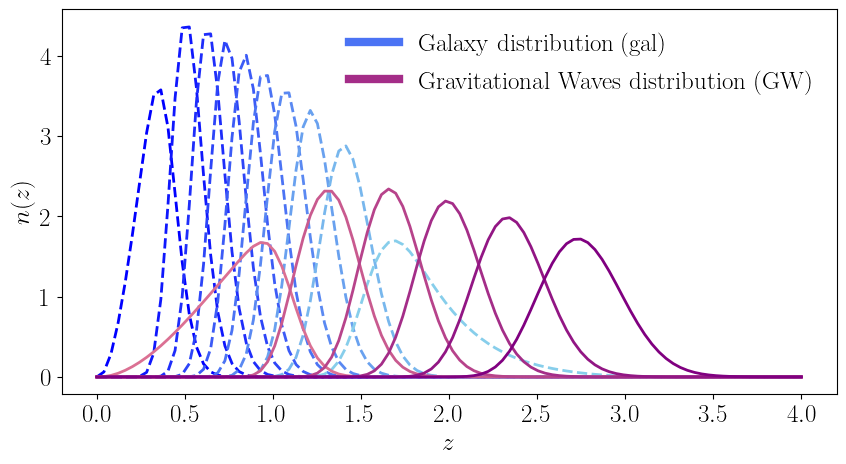

In [10]:
zplot = np.linspace(0.001, 4, 100)

plt.figure(figsize=(10, 5))
if 'GC' in observables:
    for i in range(0, Nbins_gal):
        plt.plot(zplot, distribution['GC']['dist'][i](zplot), color=gal_palette[i ],linestyle='--',linewidth=2)
if 'GWC' in observables:
    for i in range(0, Nbins_gw):
        plt.plot(zplot, distribution['GWC']['dist'][i](zplot), color=gw_palette[i ],linestyle='-',linewidth=2)

plt.xlabel(r'$z$', fontsize=18)
plt.ylabel(r'$n(z)$', fontsize=18)

legend_lines = [
    Line2D([0], [0], color=gal_palette[len(gal_palette)//2], lw=6, linestyle='-', label='Galaxy distribution (gal)'),
    Line2D([0], [0], color=gw_palette[len(gw_palette)//2], lw=6, linestyle='-', label='Gravitational Waves distribution (GW)'),
]
plt.legend(handles=legend_lines, loc='upper right', frameon=False, fontsize = 18)
plt.tick_params(axis='both', which='major', labelsize=18)


## $C_\ell$ plot

Reproducing Figure 2 of [arxiv.org/2512.19186](https://arxiv.org/abs/2512.19186)

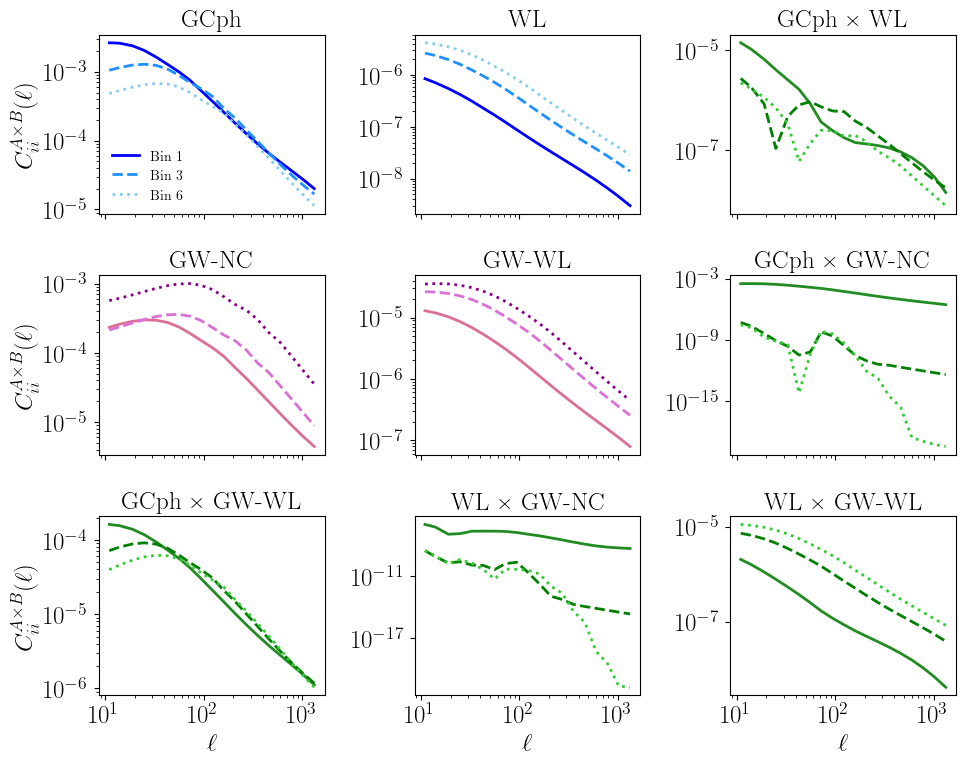

In [11]:
from matplotlib import patches as mpatches
bin_indices = [1, 3, 6]
linestyle = ['-', '--', ':']
gw_palette = ['palevioletred', 'orchid', 'darkmagenta']
cross_palette = ['forestgreen', 'green', 'limegreen']
gal_palette = ['blue', 'dodgerblue', 'skyblue']

gal_color   = 'dodgerblue'
gw_color    = 'orchid'
cross_color = 'green'

subplot_titles = [
    'GCph', 'WL', 'GCph × WL',
    'GW-NC', 'GW-WL', 'GCph × GW-NC',
    'GCph × GW-WL', 'WL × GW-NC', 'WL × GW-WL'
]

title_to_obs = [
    ('G', 'G'), ('L', 'L'), ('G', 'L'),
    ('WC', 'WC'), ('WL', 'WL'), ('G', 'WC'),
    ('G', 'WL'), ('L', 'WC'), ('L', 'WL')
]

ells = Cls_noiseless['ells']
ell_factor = ells * (ells + 1) / (2 * np.pi)

fig, axs = plt.subplots(3, 3, figsize=(10, 8), sharex=True, sharey=False)

for i, (ax, title, (obs1, obs2)) in enumerate(zip(axs.flat, subplot_titles, title_to_obs)):
    for idx, bi in enumerate(bin_indices):
        key = obs1 + str(bi) + 'x' + obs2 + str(bi)
        if key not in Cls_noiseless:
            continue

        if obs1 in ['G', 'L'] and obs2 in ['G', 'L'] and obs1 == obs2:
            color = gal_palette[idx]
        elif obs1 in ['WC', 'WL'] and obs2 in ['WC', 'WL'] and obs1 == obs2:
            color = gw_palette[idx]
        else:
            color = cross_palette[idx]


        ax.plot(
            ells,
            np.abs(Cls_noiseless[key])  * 100,
            color=color,
            linestyle=linestyle[idx],
            linewidth=2
        )

    ax.set_title(title, fontsize=18)
    ax.set_xscale('log')
    ax.set_yscale('log')

    row, col = divmod(i, 3)
    if row == 2:
        ax.set_xlabel(r'$\ell$', fontsize=18)
    else:
        ax.set_xticklabels([])
    if col == 0:
        ax.set_ylabel(r'$C_{ii}^{A \times B}(\ell)$', fontsize = 18)
    ax.tick_params(axis='both', which='both', labelleft=True)

gal_patch   = mpatches.Patch(color=gal_color, label="Galaxies")
cross_patch = mpatches.Patch(color=cross_color, label="Cross")
gw_patch    = mpatches.Patch(color=gw_color, label="GWs")
handles = [
    Line2D([0], [0], color=gal_palette[0], lw=2, label='Bin 1', ls = linestyle[0]),
    Line2D([0], [0], color=gal_palette[1], lw=2, label='Bin 3', ls = linestyle[1]),
    Line2D([0], [0], color=gal_palette[2], lw=2, label='Bin 6', ls = linestyle[2]),
]
axs[0, 0].legend(handles=handles, loc='lower left', fontsize=10, frameon = False)




plt.tight_layout()



## Saving the mocks

To save the mock_data you have to specify `mock_path`

In [12]:
mock_path = ''
if mock_path != '':
    mock.mock_data['noiseless'].to_csv(mock_path+'_Cls_noiseless.dat',sep='\t',header=True,float_format="%.24g")
    mock.mock_data['noisy'].to_csv(mock_path+'_Cls_noisy.dat',sep='\t',header=True,float_format="%.24g")
    np.save(mock_path+'_covmat.npy',mock.mock_data['covmat_dict'])
    np.save(mock_path+'_source_distribution.npy',mock.mock_data['distributions'])

## $\mu\Sigma$ CDM $C_\ell$

We compute the angular power spectra using the $\mu-\Sigma$ parametetrization taking as fiducial values $\mu_{0}=0.71$ and $\Sigma_{0}=0.19$, that correspond to the $3\sigma$ upper limits quoted in the 3rd column of [TableIV](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.107.083504)

In [13]:
fiducial_muSigma = {'ombh2': 0.022445,
            'omch2': 0.1205579307,
            'H0': 67.,
            'ns': 0.96,
            'logA': 3.05685,
            'a0': -0.007589,
            'a1': 0.002008,
            'a2': -0.004127,
            'a3': 0.002918,
            'a4': -0.0006784,
            'b0_poly': 0.830703,
            'b1_poly': 1.190547,
            'b2_poly': -0.928357,
            'b3_poly': 0.423292,
            'b0_poly_GW': 0.830703,
            'b1_poly_GW': 1.190547,
            'b2_poly_GW': -0.928357,
            'b3_poly_GW': 0.423292,
            'tau': 0.05,
            'w': -1.,
            'wa': 0.,
            'mnu': 0.06,
            'mu0': 0.71,
            'sigma0': 0.19,
            'MG_flag': 1,
            'pure_MG_flag': 2,
            'musigma_par': 1,
            'DE_model': 0}

In [14]:
from source_code.compute_obs_sources import get_obs
Cls_muSigma = get_obs(fiducial_muSigma, distribution, ells , obs_settings, feedback=False).Cls

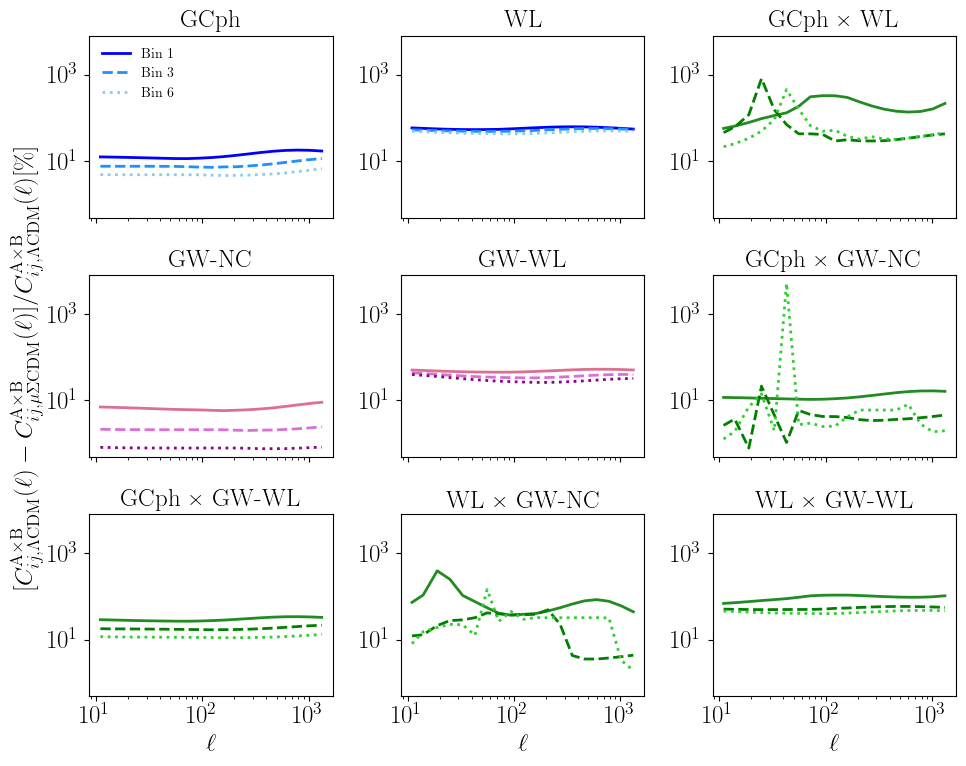

In [15]:
from matplotlib.lines import Line2D

bin_indices = [1, 3, 6]
linestyle = ['-', '--', ':']
gw_palette = ['palevioletred', 'orchid', 'darkmagenta']
cross_palette = ['forestgreen', 'green', 'limegreen']
gal_palette = ['blue', 'dodgerblue', 'skyblue']

subplot_titles = [
    'GCph', 'WL', 'GCph × WL',
    'GW-NC', 'GW-WL', 'GCph × GW-NC',
    'GCph × GW-WL', 'WL × GW-NC', 'WL × GW-WL'
]

title_to_obs = [
    ('G', 'G'), ('L', 'L'), ('G', 'L'),
    ('WC', 'WC'), ('WL', 'WL'), ('G', 'WC'),
    ('G', 'WL'), ('L', 'WC'), ('L', 'WL')
]


fig, axs = plt.subplots(3, 3, figsize=(10, 8), sharex=True, sharey=True)

for i, (ax, title, (obs1, obs2)) in enumerate(zip(axs.flat, subplot_titles, title_to_obs)):
    for idx, bi in enumerate(bin_indices):
        key = obs1 + str(bi) + 'x' + obs2 + str(bi)
        if key not in Cls_muSigma:
            continue

        if obs1 in ['G', 'L'] and obs2 in ['G', 'L'] and obs1 == obs2:
            color = gal_palette[idx]
        elif obs1 in ['WC', 'WL'] and obs2 in ['WC', 'WL'] and obs1 == obs2:
            color = gw_palette[idx]
        else:
            color = cross_palette[idx]

        ax.plot(
            ells,
            np.abs((Cls_noiseless[key]-Cls_muSigma[key])/Cls_noiseless[key])*100,
            color=color,
            linestyle=linestyle[idx],
            linewidth=2
        )

    ax.set_title(title, fontsize=18)
    ax.set_xscale('log')
    ax.set_yscale('log')

    row, col = divmod(i, 3)
    if row == 2:
        ax.set_xlabel(r'$\ell$', fontsize=18)
    else:
        ax.set_xticklabels([])

    if col == 0 and row ==1:
        ax.set_ylabel(r'$[C^{\rm A \times B}_{ij,\Lambda \rm CDM}(\ell)-C^{\rm A \times B}_{ij\rm, \mu\Sigma \rm CDM}(\ell)]/C^{\rm A\times B}_{ij\rm, \Lambda \rm CDM}(\ell)[\%]$', fontsize = 18)
       
    ax.tick_params(axis='both', which='both', labelleft=True)

handles = [
    Line2D([0], [0], color=gal_palette[0], lw=2, label='Bin 1', ls = linestyle[0]),
    Line2D([0], [0], color=gal_palette[1], lw=2, label='Bin 3', ls = linestyle[1]),
    Line2D([0], [0], color=gal_palette[2], lw=2, label='Bin 6', ls = linestyle[2]),
]
axs[0, 0].legend(handles=handles, loc='upper left', fontsize=10, frameon = False)


plt.tight_layout()



## Fiducial $\chi^2$ calculation

To run a first test we evaluate the $\chi^2$ sampling the posterior over a grid for a single parameter (test_parameter). The options are read from a file.

In [16]:
from bios import read

myfid = deepcopy(fiducial)

baseline = read('paper_settings/LCDM_3x2pt_nautilus.yaml')
del baseline['output']
baseline['likelihood']['LSS']['external']   = LSSlike
baseline['likelihood']['LSS']['data_path']  =  './test_data/LSS_GW_LCDM'
baseline['likelihood']['LSS']['debug_mode'] = False
if 'GWC' in baseline['likelihood']['LSS']['settings']['obs_used']:
    for ind in range(4):
        baseline['params']['b{}_poly_GW'.format(ind)] = baseline['params']['b{}_poly'.format(ind)]

free_pars = [par for par,val in baseline['params'].items() if type(val)==dict and 'prior' in val.keys()]

eval_dict = {}
for par,val in myfid.items():
    if par not in free_pars:
        baseline['params'][par] = val
    else:
        eval_dict[par] = val

baseline['sampler'] = {'evaluate': {'override': eval_dict}}

In [17]:
print(baseline['likelihood']['LSS'].keys())

dict_keys(['external', 'data_path', 'debug_mode', 'settings', 'use_noiseless_cls'])


- data_path : Path to the mock data
- settings :
    - cases: Turns on the relativitic effects (['redshift', 'lensing', 'velocity', 'potential', 'lsd', 'evolve', 'potential', 'gradpotential', 'ISW', 'SW', 'volume']). If None
            it won't add any of them
    - extra: extra_args to be passed to CAMB
    - obs_used: The observables you want to use in your analysis. They can be a subset of the observables for which you created the mock. The auto and cross spectra
                that you do not want to use are deleted from the covariance matrix and from the data vector.
    - camb_path
    - scale cut: If using any GW observables, you must specify the maximum multipole $\ell_{\rm max}$. **Note**: The code currently forces a single $\ell_{\rm max}$ for the analysis. Because galaxies are expected to have a higher $\ell_{\rm max}$, theoretical values are computed up to the galaxy limit, and all auto and cross-spectra involving GWs are subsequently cut at your specified $\ell_{\rm max}$.
- use_noiseless_cls: True if you want noiseless, False if you want noisy

### Likelihood noiseless

In [18]:
baseline['likelihood']['LSS']['use_noiseless_cls'] = True
updated_info,sampler = run(baseline)

Using noiseless Cls
Observables used: ['GC', 'WL']
[evaluate] Initialized!
[evaluate] Looking for a reference point with non-zero prior.
[evaluate] Reference point:
   ombh2 = 0.022445
   omch2 = 0.120558
   ns = 0.96
   H0 = 67
   logA = 3.05685
   a0 = -0.007589
   a1 = 0.002008
   a2 = -0.004127
   a3 = 0.002918
   a4 = -0.0006784
   b0_poly = 0.830703
   b1_poly = 1.19055
   b2_poly = -0.928357
   b3_poly = 0.423292
[evaluate] Evaluating prior and likelihoods...
[evaluate] log-posterior  = 64.6482
[evaluate] log-prior      = 64.6482
[evaluate]    logprior_0 = 64.6482
[evaluate] log-likelihood = -8.1334e-25
[evaluate]    chi2_LSS = 1.62668e-24
[evaluate] Derived params:
[evaluate]    As = 2.12605e-09
[evaluate]    omegab = 0.05
[evaluate]    omegam = 0.319998


### Likelihood noisy

In [19]:
baseline['likelihood']['LSS']['use_noiseless_cls'] = False
updated_info,sampler = run(baseline)

Using noisy Cls
Observables used: ['GC', 'WL']
[evaluate] Initialized!
[evaluate] Looking for a reference point with non-zero prior.
[evaluate] Reference point:
   ombh2 = 0.022445
   omch2 = 0.120558
   ns = 0.96
   H0 = 67
   logA = 3.05685
   a0 = -0.007589
   a1 = 0.002008
   a2 = -0.004127
   a3 = 0.002918
   a4 = -0.0006784
   b0_poly = 0.830703
   b1_poly = 1.19055
   b2_poly = -0.928357
   b3_poly = 0.423292
[evaluate] Evaluating prior and likelihoods...
[evaluate] log-posterior  = -1449.65
[evaluate] log-prior      = 64.6482
[evaluate]    logprior_0 = 64.6482
[evaluate] log-likelihood = -1514.3
[evaluate]    chi2_LSS = 3028.6
[evaluate] Derived params:
[evaluate]    As = 2.12605e-09
[evaluate]    omegab = 0.05
[evaluate]    omegam = 0.319998


## Grid $\chi^2$ test

In [20]:
run_grid_test = True
test_parameter = {'name': 'H0',
                  'variation': 0.1,
                  'latex': r'$H_0$',
                  'Ngrid': 10,
                  'noiseless_like': True}

In [21]:
if run_grid_test:
    test_par_vec = np.linspace(63,75,10)
    
    if fiducial[test_parameter['name']] not in test_par_vec:
        test_par_vec = np.append(test_par_vec,fiducial[test_parameter['name']])
    
    baseline['likelihood']['LSS']['use_noiseless_cls'] = test_parameter['noiseless_like']
    
    dfs = []
    for val in test_par_vec:
        eval_dict[test_parameter['name']] = val
        baseline['sampler'] = {'evaluate': {'override': eval_dict}}
        updated_info, sampler = run(baseline)
    
        dfs.append(pd.DataFrame({test_parameter['latex']: val,
                                 r'$\chi^2$': -2*sampler.logposterior.loglike},index=[0]))
    
    chi2_df = pd.concat(dfs,ignore_index=True)

Using noiseless Cls
Observables used: ['GC', 'WL']
[evaluate] Initialized!
[evaluate] Looking for a reference point with non-zero prior.
[evaluate] Reference point:
   ombh2 = 0.022445
   omch2 = 0.120558
   ns = 0.96
   H0 = 63
   logA = 3.05685
   a0 = -0.007589
   a1 = 0.002008
   a2 = -0.004127
   a3 = 0.002918
   a4 = -0.0006784
   b0_poly = 0.830703
   b1_poly = 1.19055
   b2_poly = -0.928357
   b3_poly = 0.423292
[evaluate] Evaluating prior and likelihoods...
[evaluate] log-posterior  = -6423.27
[evaluate] log-prior      = 64.6482
[evaluate]    logprior_0 = 64.6482
[evaluate] log-likelihood = -6487.92
[evaluate]    chi2_LSS = 12975.8
[evaluate] Derived params:
[evaluate]    As = 2.12605e-09
[evaluate]    omegab = 0.0565508
[evaluate]    omegam = 0.361923
Using noiseless Cls
Observables used: ['GC', 'WL']
[evaluate] Initialized!
[evaluate] Looking for a reference point with non-zero prior.
[evaluate] Reference point:
   ombh2 = 0.022445
   omch2 = 0.120558
   ns = 0.96
   H0 = 64

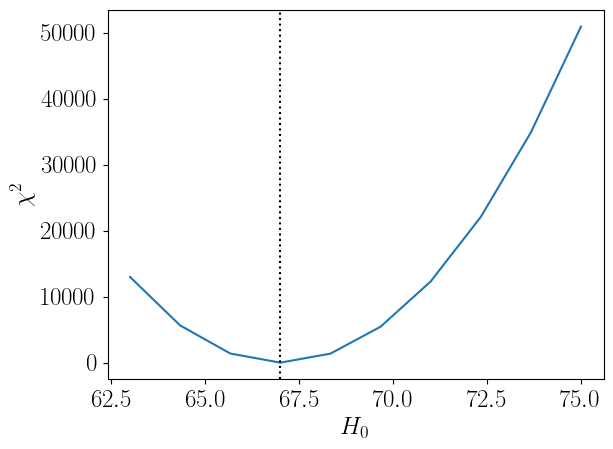

In [22]:
if run_grid_test:
    plt.figure()
    sb.lineplot(chi2_df,x=test_parameter['latex'],y=r'$\chi^2$')
    plt.axvline(x=mock.fiducial[test_parameter['name']],ls=':',color='black');

## Fisher matrix

Example on how to run a Fisher matrix

In [23]:
from samplers.samplers_interface import run_fisher
from bios import read
info = read('paper_settings/muSigmaCDM_fisher_3x2pt+GW.yaml')

In [25]:
print(info['analysis_settings'].keys())
print(info['sampler']['Fisher'].keys())
print('Using the following observables in the Fisher forecast:', info['analysis_settings']['observables'])

dict_keys(['observables', 'lmin', 'lmax', 'Nbin_ell', 'galaxy_specs', 'gw_specs'])
dict_keys(['derivative', 'freepars', 'fixedpars'])
Using the following observables in the Fisher forecast: ['GC', 'WL', 'GWC']


The observables you want to use must be specified in info['analysis_settings']['observables'], e.g.   observables: [GC,WL,GWC]

The settings for the Fisher calculation are specified in info['sampler']['Fisher']
- derivative: Available derivatives options: 2PT (faster) polynomial (more accurate)
- freepars: The parameters considered in the evaluation of the fisher. You must give a dictionary with the following structure 'par_name': {'fiducial': value, 'variation': value, 'latex': name}
- fixedpars: The parameters kept fixed 

In [29]:
fishmat,info_dict  = run_fisher(info)
fishmat.to_csv(info['output']+'_matrix.txt',sep='\t',header=True,index=False)
np.save(info['output']+'_info.npy',info_dict)

Creating source distributions

Computing fiducial observables ... 
 ...done in 9.06 s

Computing covariance matrix ... 
... done in 0.20 s

Computing derivatives ... 
... computing derivative for ombh2 ...
... computing derivative for omch2 ...
... computing derivative for H0 ...
... computing derivative for ns ...
... computing derivative for logA ...
... computing derivative for a0 ...
... computing derivative for a1 ...
... computing derivative for a2 ...
... computing derivative for a3 ...
... computing derivative for a4 ...
... computing derivative for b0_poly ...
... computing derivative for b1_poly ...
... computing derivative for b2_poly ...
... computing derivative for b3_poly ...
... computing derivative for b0_poly_GW ...
... computing derivative for b1_poly_GW ...
... computing derivative for b2_poly_GW ...
... computing derivative for b3_poly_GW ...
... computing derivative for mu0 ...
... computing derivative for sigma0 ...
... done in 383.83 s


In [30]:
info['output'] = 'chains/muSigmaCDM_3x2pt+GWC_fisher_rel'
info['obs_settings']['cases'] = ['lensing', 'velocity', 'lsd']
fishmat_rel,info_dict_rel  = run_fisher(info)
fishmat_rel.to_csv(info['output']+'_matrix.txt',sep='\t',header=True,index=False)
np.save(info['output']+'_info.npy',info_dict_rel)

Creating source distributions
You are adding the following contributions to the source terms: ['lensing', 'velocity', 'lsd']. This part of the code is still under validation, so please be careful.

Computing fiducial observables ... 
 ...done in 13.41 s

Computing covariance matrix ... 
... done in 0.20 s

Computing derivatives ... 
... computing derivative for ombh2 ...
... computing derivative for omch2 ...
... computing derivative for H0 ...
... computing derivative for ns ...
... computing derivative for logA ...
... computing derivative for a0 ...
... computing derivative for a1 ...
... computing derivative for a2 ...
... computing derivative for a3 ...
... computing derivative for a4 ...
... computing derivative for b0_poly ...
... computing derivative for b1_poly ...
... computing derivative for b2_poly ...
... computing derivative for b3_poly ...
... computing derivative for b0_poly_GW ...
... computing derivative for b1_poly_GW ...
... computing derivative for b2_poly_GW ...
.

In [31]:
Fisher_results = {
    r'$\mu\Sigma$CDM 3 $\times$ 2 pt + GW': {'path': 'chains/muSigmaCDM_3x2pt+GWC_fisher',      
                                                'sampler': 'Fisher',
                                                'color': 'yellowgreen',
                                                'filled': True,
                                                'alpha': 0.7,
                                                'covmat': False},
                r'$\mu\Sigma$CDM 3 $\times$ 2 pt + GW with relativistic effects': {'path': 'chains/muSigmaCDM_3x2pt+GWC_fisher_rel',      
                                                'sampler': 'Fisher',
                                                'color': 'plum',
                                                'filled': True,
                                                'alpha': 0.7,
                                                'covmat': False},
                                                }

In [32]:

analysis_settings = {'Metropolis-Hastings': {'ignore_rows': 0.3},
                     'Nautilus': {}}

In [33]:
from analysis.chains_analysis import Analyzer
stats = Analyzer(analysis_settings, fiducial)

In [34]:
from getdist.gaussian_mixtures import GaussianND
from getdist import plots,loadMCSamples,MCSamples

import pprint
names = {'ombh2': '$\Omega_b h^2$',
         'omch2': '$\Omega_c h^2$',
         'ns': '$n_s$',
            'H0': '$H_0$',
            'mu0': '$\mu_0$',
            'sigma0': '$\Sigma_0$',
            'logA': '$\log(10^{10}A_s)$',
            'b0_poly': '$b_0$',
            'b1_poly': '$b_1$',
            'b2_poly': '$b_2$',
            'b3_poly': '$b_3$',
            'b0_poly_GW': '$b_0^{GW}$',
            'b1_poly_GW': '$b_1^{GW}$',
            'b2_poly_GW': '$b_2^{GW}$',
            'b3_poly_GW': '$b_3^{GW}$',
            'a0': '$a_0$',
            'a1': '$a_1$',
            'a2': '$a_2$',
            'a3': '$a_3$',
            'a4': '$a_4$',}


def print_dict(d,indent=4):
    for k,v in d.items():
        print('')
        print('\x1b[1;31m'+k+'\x1b[0m')
        pprint.PrettyPrinter(indent=indent).pprint(v)

    return None

def get_chain_info(info):
    chain_info = deepcopy(info)
    chain_info = np.load(info['path']+'_info.npy',allow_pickle=True).item()
    return chain_info

def analyze_chain(name,info):
     
    print(info['sampler'])
    chain_info = get_chain_info(info)
    chain_report = deepcopy(chain_info)
    print(chain_report.keys())
    print('')
    print('\x1b[1;31m Analyzing {} \x1b[0m'.format(name))
    add_bbn = True
    fisher = pd.read_csv(info['path']+'_matrix.txt',header=0,sep='\s+')
    fisher.index = fisher.columns
    if add_bbn:
                sigma_bbn = 0.00055
                fisher.at['ombh2','ombh2'] += 1/sigma_bbn**2
    for par in fisher.columns:
        chain_info[par]['latex']=names[par]


    sample = GaussianND([chain_info[par]['fiducial'] for par in fisher.columns], 
                        np.linalg.inv(fisher.values),
                        names=fisher.columns, 
                        labels=[chain_info[par]['latex'] for par in fisher.columns]).MCSamples(10000)
    
    param_names = sample.getParamNames().list()
    chain_report['MCsamples'] = sample
    chain_report['bounds'] = sample.getTable(limit=1).tableTex()
    print(chain_report['bounds'])
    all_pars     = sample.getParamNames().list()
    labels       = sample.getParamNames().labels()
    primary_pars = sample.getParamNames().getRunningNames()
    means    = {par:val for par,val in zip(all_pars,sample.getMeans())}
    discard  = ['weight','minuslogpost','minuslogprior', 
                'minuslogprior__0']
    try:
        best_fit = sample.getParamBestFitDict()
    except:
        print('no .minimum file available for {}. Switching to best sample'.format(name))
        try:
            best_fit = sample.getParamBestFitDict(best_sample=True)
        except:
            print('Best sample unavailable for some reason. Using means as best fit (DO NOT TRUST THIS!)')
            best_fit = deepcopy(means)

    try:
        best_fit['chi2'] = 2*best_fit['loglike']
    except:
        print('Best fit chi2 not available')
    chain_report['Estimators'] = pd.DataFrame.from_dict({par: [means[par],best_fit[par]] for par in all_pars if par not in discard})
    chain_report['Estimators']['Type']      = ['Mean','Best-Fit']
    chain_report['Estimators']['Cosmology'] = name
    
    all_pars     = sample.getParamNames().list()
    labels       = sample.getParamNames().labels()
    primary_pars = sample.getParamNames().getRunningNames()
    means    = {par:val for par,val in zip(all_pars,sample.getMeans())}
    discard  = ['weight','minuslogpost','minuslogprior', 
                'minuslogprior__0']

    chain_report['Sampled points']              = pd.DataFrame(sample.makeSingleSamples(),columns=all_pars)
    chain_report['Sampled points']['Cosmology'] = name
    covmat = pd.DataFrame(sample.getCovMat().matrix,columns=sample.getCovMat().paramNames,index=sample.getCovMat().paramNames)
    chain_report['covmat'] = covmat
    return chain_report




In [35]:
results = {name: analyze_chain(name,chain) for name,chain in Fisher_results.items()} 

Fisher
dict_keys(['ombh2', 'omch2', 'H0', 'ns', 'logA', 'a0', 'a1', 'a2', 'a3', 'a4', 'b0_poly', 'b1_poly', 'b2_poly', 'b3_poly', 'b0_poly_GW', 'b1_poly_GW', 'b2_poly_GW', 'b3_poly_GW', 'mu0', 'sigma0'])

 Analyzing $\mu\Sigma$CDM 3 $\times$ 2 pt + GW 
\begin{tabular} { l  c}

 Parameter &  68\% limits\\
\hline
{\boldmath$\Omega_b h^2$ } & $0.02245\pm 0.00061        $\\

{\boldmath$\Omega_c h^2$ } & $0.1205\pm 0.0061          $\\

{\boldmath$H_0$          } & $67.0\pm 3.2               $\\

{\boldmath$n_s$          } & $0.960\pm 0.012            $\\

{\boldmath$\log(10^{10}A_s)$} & $3.057\pm 0.074            $\\

{\boldmath$a_0$          } & $-0.00759\pm 0.00030       $\\

{\boldmath$a_1$          } & $0.0020\pm 0.0012          $\\

{\boldmath$a_2$          } & $-0.0041\pm 0.0029         $\\

{\boldmath$a_3$          } & $0.0029\pm 0.0028          $\\

{\boldmath$a_4$          } & $-0.00068\pm 0.00072       $\\

{\boldmath$b_0$          } & $0.8306\pm 0.0082          $\\

{\boldmath$b_

In [36]:
cosmo_pars = ['ombh2', 'omch2', 'H0', 'ns', 'logA']

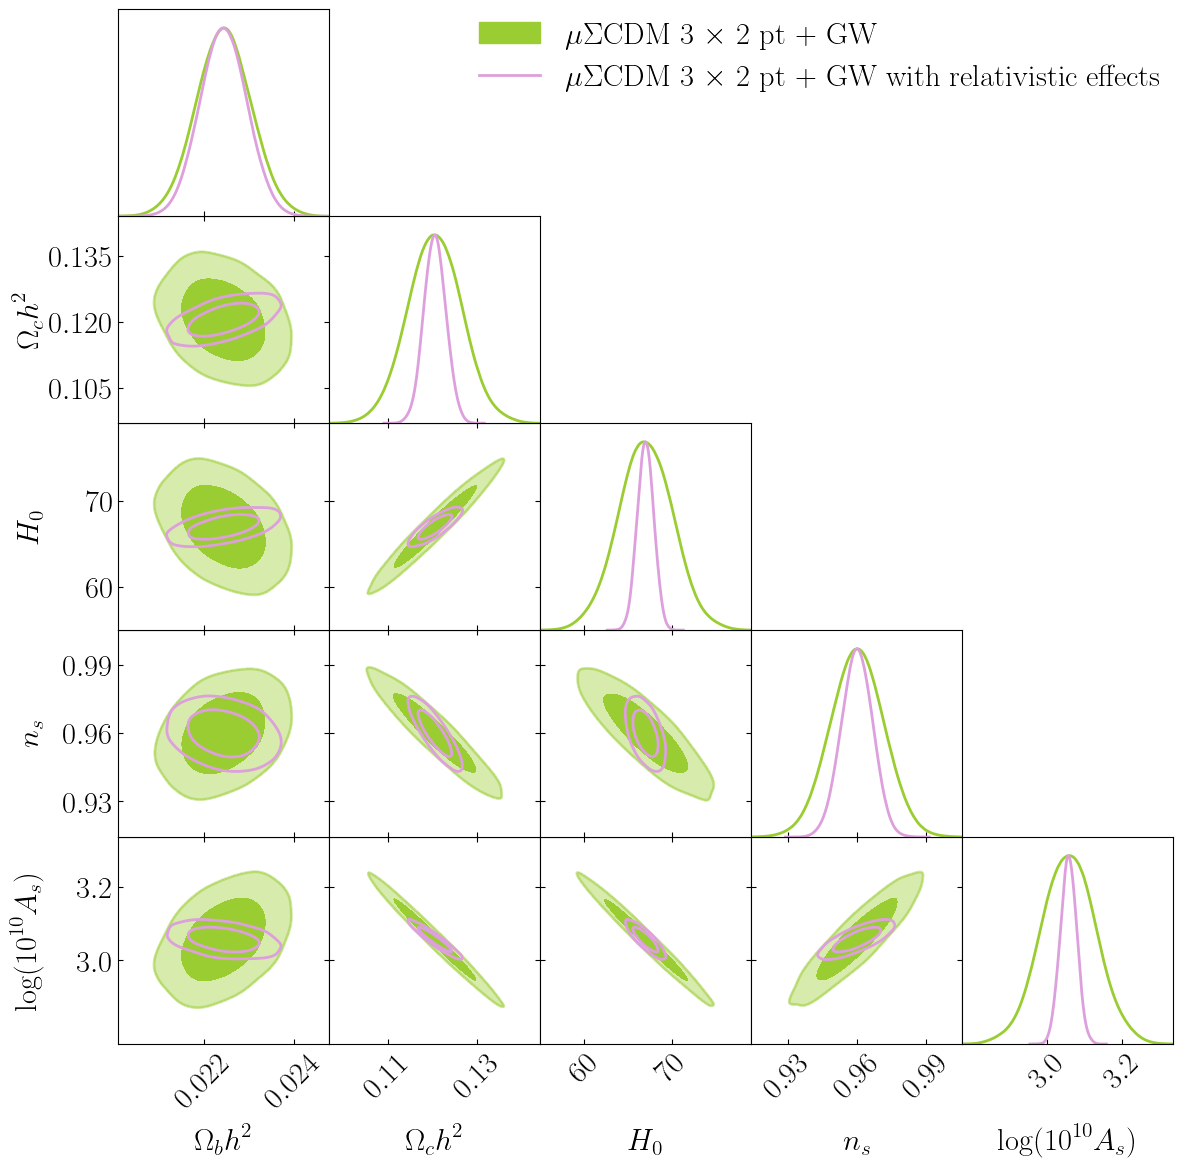

In [37]:
from getdist import plots

g = plots.get_subplot_plotter(subplot_size=1,width_inch=12, scaling=False)
g.settings.figure_legend_frame = False
g.settings.axes_fontsize=22
g.settings.axes_labelsize=22
g.settings.legend_fontsize=22
g.settings.axis_marker_color = 'black'
g.settings.axis_marker_ls = '--'
g.settings.axis_marker_lw = 1
g.settings.axis_tick_x_rotation = 45
g.triangle_plot([result['MCsamples'] for result in results.values()], cosmo_pars,
    filled=[True, False],
    legend_loc='upper right',
    legend_labels=[result for result in results.keys()],
    contour_colors=['yellowgreen', 'plum'],
    contour_lws=2,
    )    
g.fig.align_ylabels()
g.fig.align_xlabels()
